# DATASET:
https://www.kaggle.com/datasets/oktayrdeki/houses-in-london 

The dataset used in this paper is the London Houses Dataset, which includes information about houses in London and their corresponding selling prices.

The dataset contains many important features that affect house prices, such as:

- Neighborhood
- Bedrooms
- Bathrooms
- Square Meters
- Building Age
- Floors
- Property Type
- Garden
- Garage
- Heating Type
- Balcony
- Interior Style
- View
- Materials
- Building Status

In this project, the dataset was used to predict the Price (£) of houses using a Multilayer Neural Network (MLP) regression model and other supervised regression techniques.

Exploratory Data Analysis - EDA the goal of this lab is to perform EDA analysis based on the dataset (london_houses.csv).

## 1. Tổng quan về bộ dữ liệu (Dataset Overview)

In [43]:
# Import thư viện
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [44]:
# Đọc dữ liệu
df = pd.read_csv("london_houses.csv")

# Xem 5 dòng đầu
df.head()

# Kích thước dữ liệu
print(df.shape)

# Thông tin dữ liệu
df.info()

# Thống kê mô tả
df.describe()


(1000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Address          1000 non-null   str  
 1   Neighborhood     1000 non-null   str  
 2   Bedrooms         1000 non-null   int64
 3   Bathrooms        1000 non-null   int64
 4   Square Meters    1000 non-null   int64
 5   Building Age     1000 non-null   int64
 6   Garden           1000 non-null   str  
 7   Garage           1000 non-null   str  
 8   Floors           1000 non-null   int64
 9   Property Type    1000 non-null   str  
 10  Heating Type     1000 non-null   str  
 11  Balcony          1000 non-null   str  
 12  Interior Style   1000 non-null   str  
 13  View             1000 non-null   str  
 14  Materials        1000 non-null   str  
 15  Building Status  1000 non-null   str  
 16  Price (£)        1000 non-null   int64
dtypes: int64(6), str(11)
memory usage: 132.9 KB


,Bedrooms,Bathrooms,Square Meters,Building Age,Floors,Price (£)
count,1000.000000,1000.000000,1000.0000,1000.00000,1000.000000,1.000000e+03
mean,3.013000,2.003000,149.6270,49.96500,1.991000,1.840807e+06
std,1.393834,0.808483,58.0562,29.07086,0.821946,8.793484e+05
min,1.000000,1.000000,50.0000,1.00000,1.000000,3.866660e+05
25%,2.000000,1.000000,99.0000,24.00000,1.000000,1.161400e+06
50%,3.000000,2.000000,148.0000,50.00000,2.000000,1.721999e+06
75%,4.000000,3.000000,201.0000,76.00000,3.000000,2.390500e+06
max,5.000000,3.000000,249.0000,99.00000,3.000000,4.980000e+06


=> Nhận xét: Bộ dữ liệu gồm 1000 mẫu và 17 thuộc tính.Biến mục tiêu là Price (£).Dataset gồm cả thuộc tính số và thuộc tính phân loại.Không phát hiện sai kiểu dữ liệu nên chưa cần chuyển đổi.

In [45]:
# Kiểm tra dữ liệu có bị missing không 
missing = df.isnull().sum()

print(missing)

Address            0
Neighborhood       0
Bedrooms           0
Bathrooms          0
Square Meters      0
Building Age       0
Garden             0
Garage             0
Floors             0
Property Type      0
Heating Type       0
Balcony            0
Interior Style     0
View               0
Materials          0
Building Status    0
Price (£)          0
dtype: int64


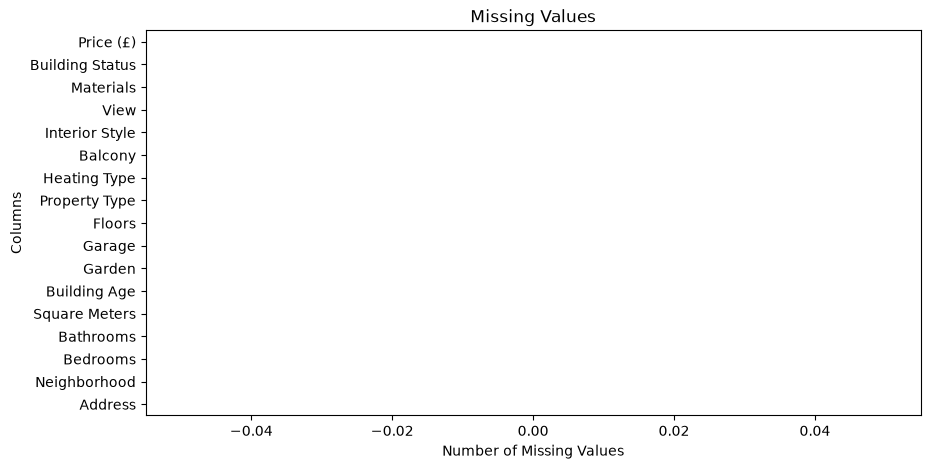

In [46]:
#Trực quan hóa số lượng giá trị thiếu của từng thuộc tính
plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')
plt.title("Missing Values")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()

In [47]:
# Kiểm tra dữ liệu có bị trùng lặp không
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


## 2. Phân tích đơn biến (Univariate Analysis)

### Phân bố của biến Price (£)

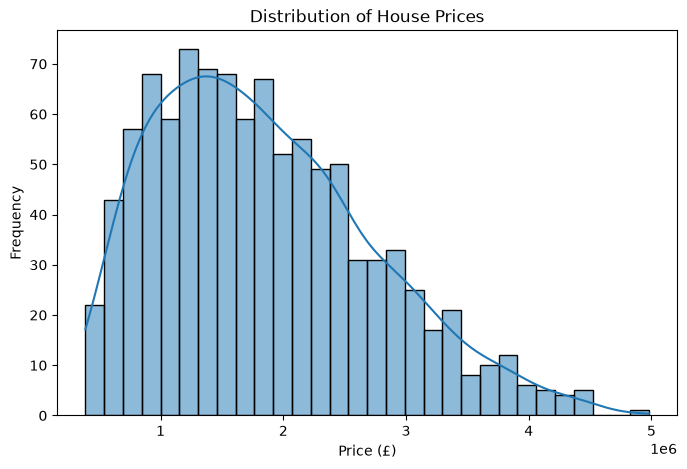

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price (£)"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

## Kiểm tra độ lệch (Skewness) của Price (£)

In [49]:
print(
    "Price Skewness:",
    df["Price (£)"].skew()
)

Price Skewness: 0.6513082699899329


## Boxplot phát hiện ngoại lệ của Price (£)

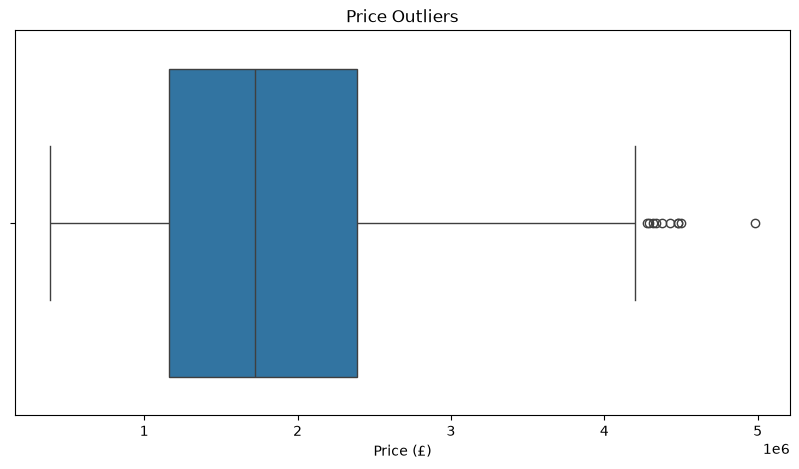

In [50]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Price (£)"]
)

plt.title(
    "Price Outliers"
)

plt.show()

## Phân phối số lượng phòng ngủ (Bedrooms)

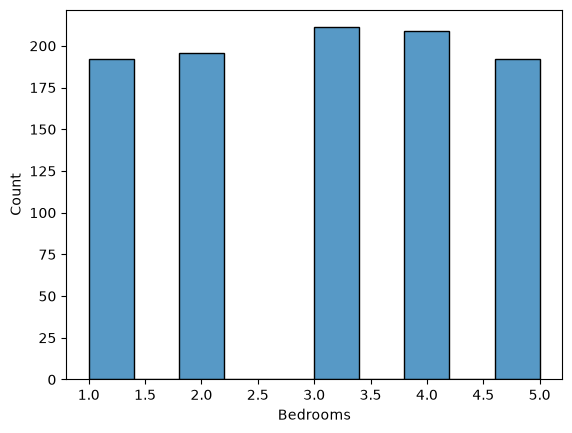

In [51]:
sns.histplot(
    df["Bedrooms"],
    bins=10
)

plt.show()

## Phân phối số lượng phòng tắm (Bathrooms)

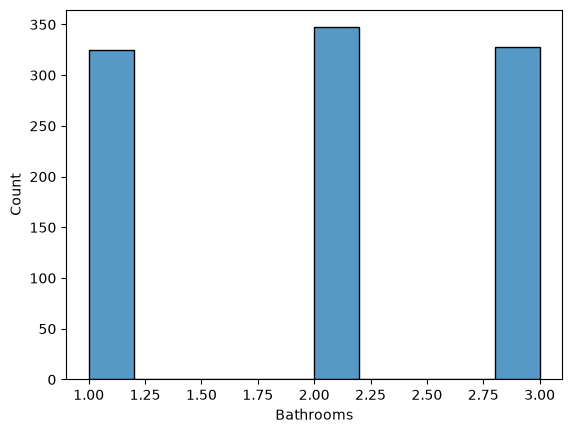

In [52]:
sns.histplot(
    df["Bathrooms"],
    bins=10
)

plt.show()

## Phân phối diện tích nhà (Square Meters)

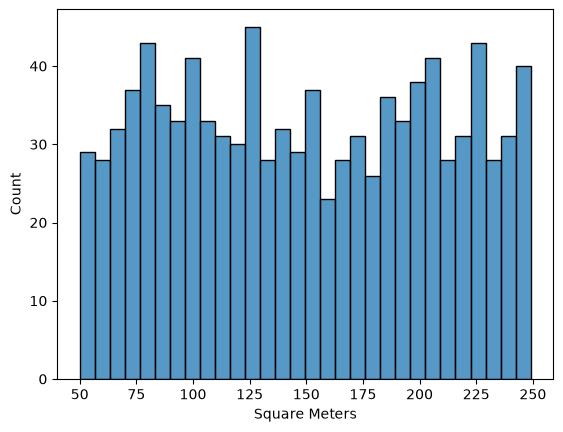

In [53]:
sns.histplot(
    df["Square Meters"],
    bins=30
)

plt.show()

## Phân phối tuổi của ngôi nhà (Building Age)

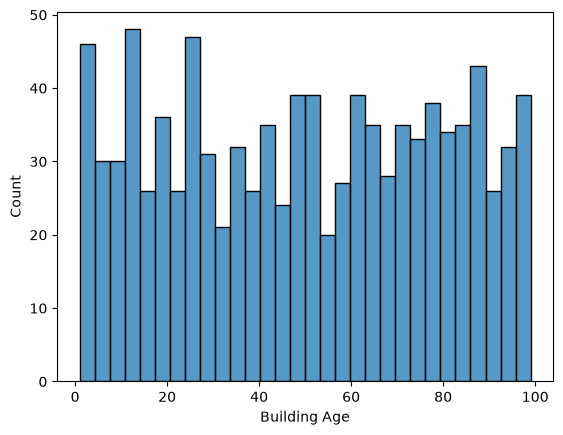

In [54]:
sns.histplot(
    df["Building Age"],
    bins=30
)

plt.show()

# 3. Phân tích biến phân loại (Categorical Analysis)

## Thống kê số lượng theo Neighborhood

In [55]:
print(
    df["Neighborhood"]
    .value_counts()
)

Neighborhood
Kensington      114
Marylebone      113
Camden          106
Westminster      98
Islington        97
Greenwich        97
Notting Hill     96
Soho             96
Chelsea          94
Shoreditch       89
Name: count, dtype: int64


## Thống kê số lượng theo Property Type

In [56]:
print(
    df["Property Type"]
    .value_counts()
)

Property Type
Detached House    349
Semi-Detached     345
Apartment         306
Name: count, dtype: int64


## Biểu đồ phân bố Property Type

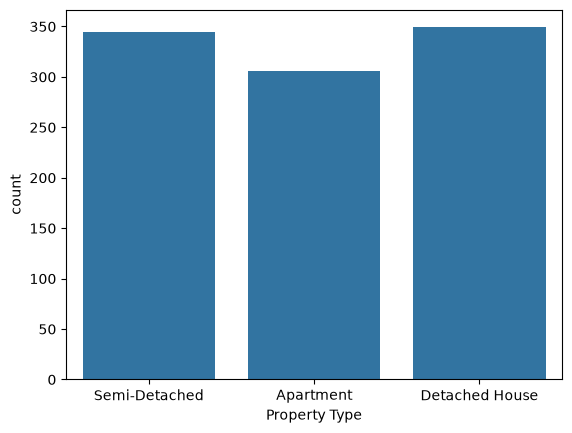

In [57]:
sns.countplot(
    x=df["Property Type"]
)

plt.show()

# 4. Phân tích tương quan (Correlation Analysis)

## Ma trận tương quan giữa các thuộc tính số

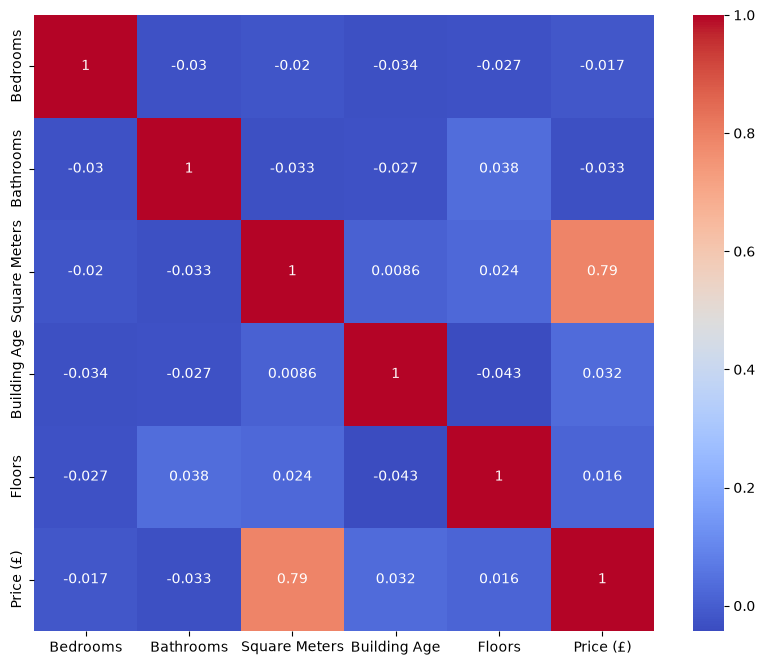

In [58]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

# 5. Phân tích hai biến (Bivariate Analysis)

## Mối quan hệ giữa Square Meters và Price (£)

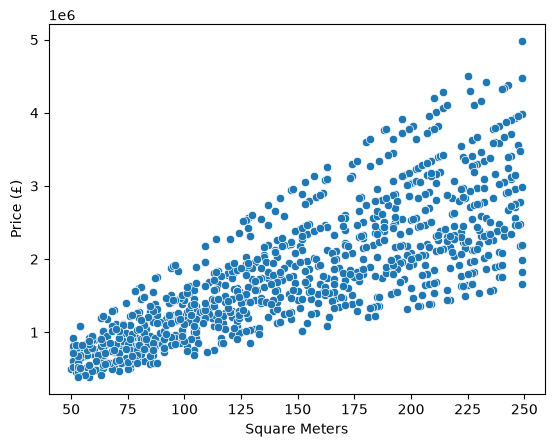

In [59]:
sns.scatterplot(
    x=df["Square Meters"],
    y=df["Price (£)"]
)

plt.show()

## Mối quan hệ giữa Building Age và Price (£)

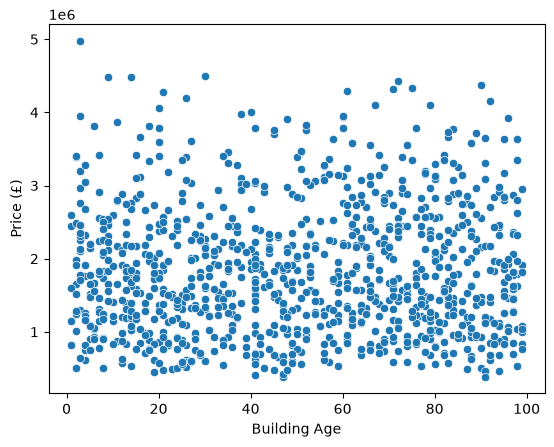

In [60]:
sns.scatterplot(
    x=df["Building Age"],
    y=df["Price (£)"]
)

plt.show()

## So sánh giá nhà theo từng Property Type

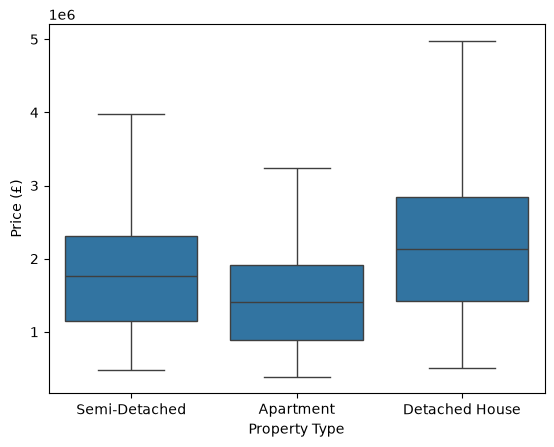

In [61]:
sns.boxplot(
    x=df["Property Type"],
    y=df["Price (£)"]
)

plt.show()

## Giá trung bình của từng Property Type

In [62]:
df.groupby(
    "Property Type"
)["Price (£)"].mean()

Property Type
Apartment         1.469727e+06
Detached House    2.191272e+06
Semi-Detached     1.815411e+06
Name: Price (£), dtype: float64

## Bảng chéo giữa Garage và Garden (Chi-square Test)

In [63]:

table = pd.crosstab(
    df["Garage"],
    df["Garden"]
)

chi2, p, dof, expected = \
    chi2_contingency(table)

print("p-value =", p)

p-value = 1.0


## 6. Phát hiện ngoại lệ (Outlier Detection bằng IQR)

In [64]:
Q1 = df["Price (£)"].quantile(0.25)
Q3 = df["Price (£)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = \
    Q1 - 1.5 * IQR

upper_bound = \
    Q3 + 1.5 * IQR

outliers = df[
    (df["Price (£)"] < lower_bound)
    |
    (df["Price (£)"] > upper_bound)
]

print(
    "Number of Outliers:",
    len(outliers)
)

Number of Outliers: 10


## 7. Pairplot - Quan sát mối quan hệ giữa các thuộc tính số

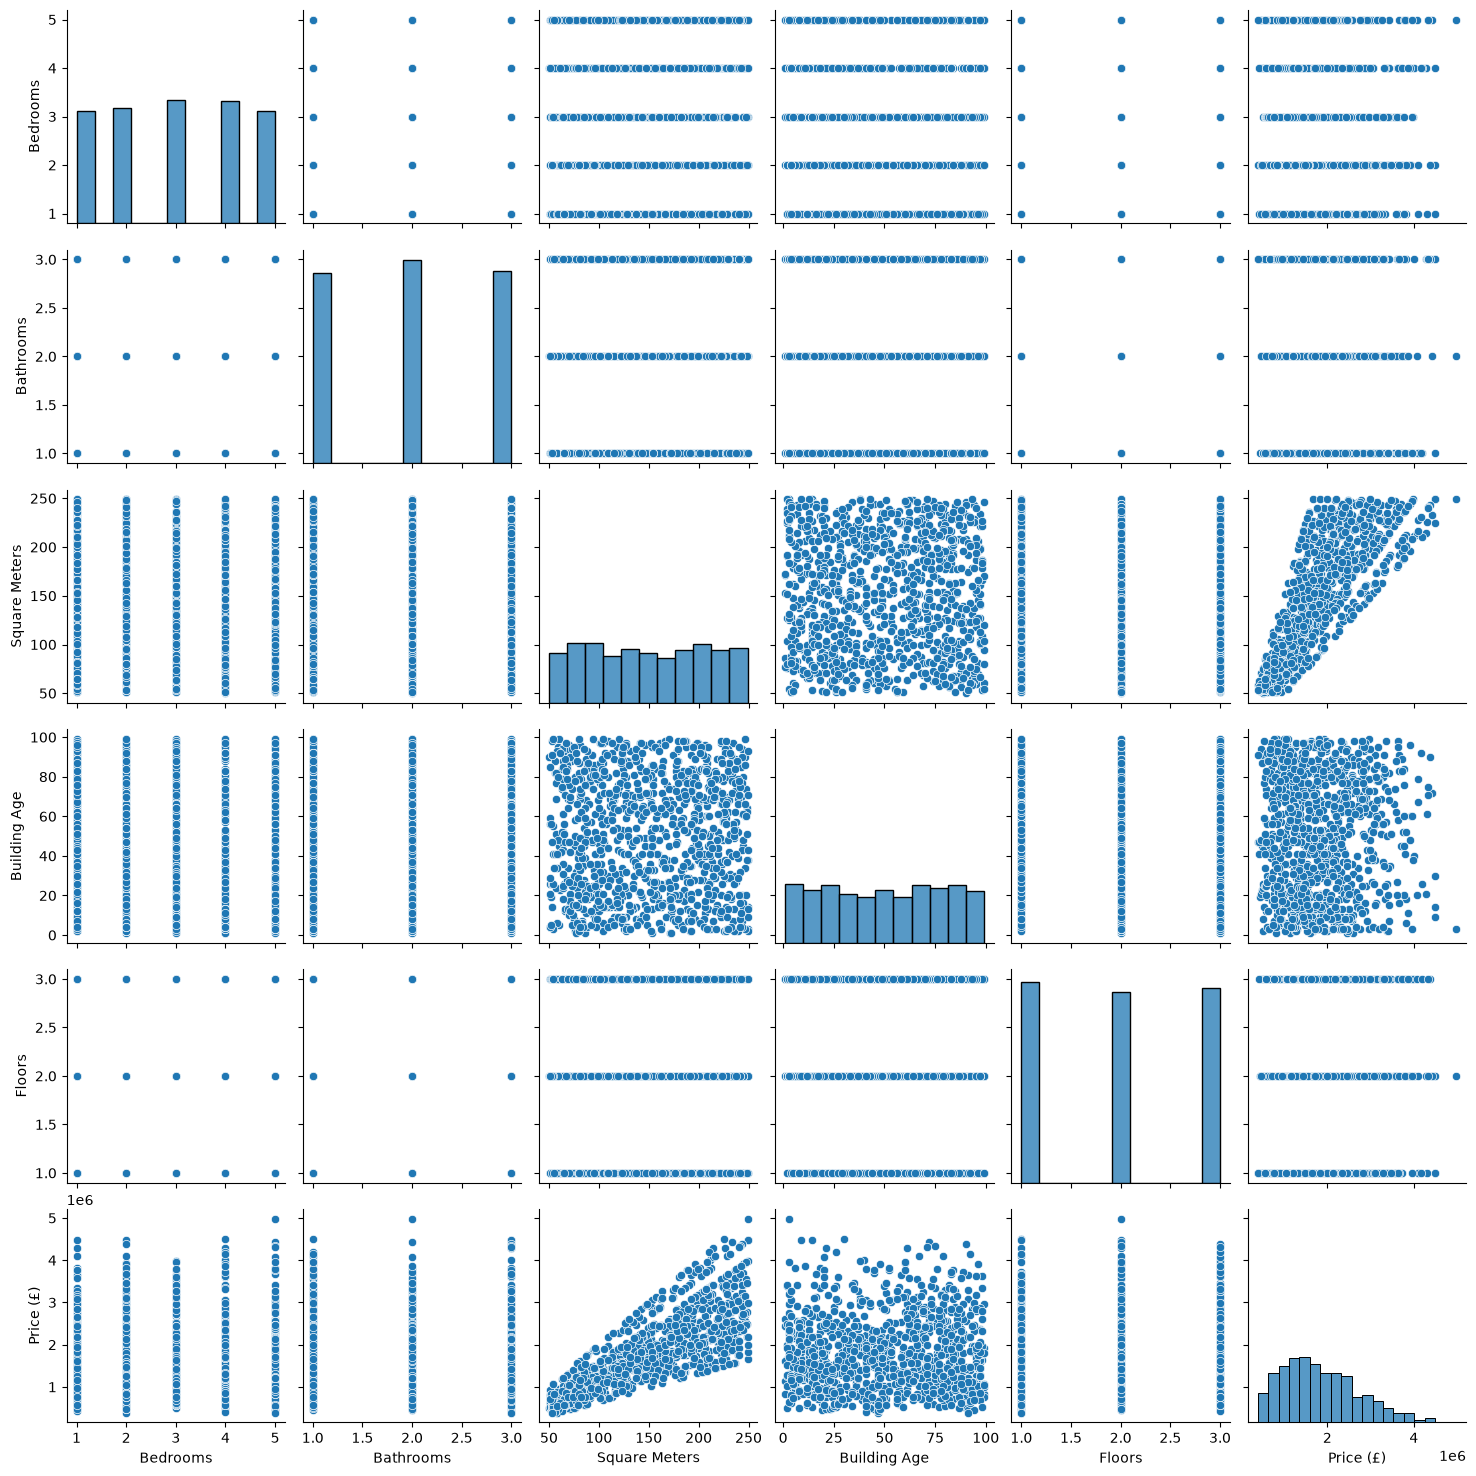

In [65]:
sns.pairplot(
    numeric_df
)

plt.show()

# Kỹ thuật Đặc trưng (Feature Engineering)

Feature Engineering (Kỹ thuật đặc trưng) là quá trình biến đổi, tạo mới, lựa chọn và chuẩn bị các đặc trưng trước khi huấn luyện mô hình Machine Learning hoặc Deep Learning. Mục tiêu là nâng cao chất lượng dữ liệu, cải thiện hiệu suất của mô hình và giảm ảnh hưởng của các đặc trưng nhiễu hoặc không cần thiết.

Trong dự án này, bộ dữ liệu sau khi được xử lý sẽ được sử dụng để huấn luyện mô hình **Multilayer Perceptron (MLP)** được xây dựng bằng **PyTorch**.

## 1. Mã hóa biến phân loại ( Feature Encoding)

In [67]:
# 3.1 Label Encoding
# Áp dụng cho các biến có thứ tự (Ordinal Features)
# Quy định thứ tự của biến Balcony
balcony_mapping = {
    'No Balcony': 0,
    'Low-level Balcony': 1,
    'High-level Balcony': 2
}
# Quy định thứ tự của biến Building Status
building_status_mapping = {
    'Old': 0,
    'Renovated': 1,
    'New': 2
}
# Thay thế giá trị chuỗi bằng số nguyên
df["Balcony"] = df["Balcony"].map(balcony_mapping)
df["Building Status"] = df["Building Status"].map(building_status_mapping)
# 3.2 One-Hot Encoding
# Áp dụng cho các biến không có thứ tự
# Danh sách các biến sẽ One-Hot Encoding
one_hot_cols = [
    "Neighborhood",
    "Garden",
    "Garage",
    "Property Type",
    "Heating Type",
    "Interior Style",
    "View",
    "Materials"
]
# Loại bỏ cột Address vì chỉ là mã định danh,
# không mang nhiều ý nghĩa trong dự đoán giá nhà
# Chỉ xóa nếu cột còn tồn tại
if "Address" in df.columns:
    df = df.drop(columns=["Address"])

# Chỉ One-Hot nếu các cột vẫn còn tồn tại
cols = [c for c in one_hot_cols if c in df.columns]

if len(cols) > 0:
    df = pd.get_dummies(df, columns=cols, dtype=int)
# Kiểm tra kết quả sau khi mã hóa
print(df.head())
# Kiểm tra kích thước dữ liệu sau Encoding
print(df.shape)

   Bedrooms  Bathrooms  Square Meters  Building Age  Floors  Balcony  \
0         2          3            179            72       3      NaN   
1         2          1            123            34       1      NaN   
2         5          3            168            38       3      NaN   
3         5          1            237            53       1      NaN   
4         4          1            127            23       2      NaN   

   Building Status  Price (£)  Neighborhood_0  Neighborhood_1  ...  \
0              NaN    2291200               1               0  ...   
1              NaN    1476000               0               1  ...   
2              NaN    1881600               0               0  ...   
3              NaN    1896000               0               0  ...   
4              NaN    1524000               0               0  ...   

   Interior Style_3  View_0  View_1  View_2  View_3  View_4  Materials_0  \
0                 0       1       0       0       0       0           

### 2. Tạo đặc trưng mới (Feature Creation)

Tạo thêm các đặc trưng mới từ dư liệu hiện có nhằm giúp mô hình MLP học được nhiều thông tin hơn.

In [71]:
# Tổng số phòng
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]

# Mật độ phòng trên diện tích
df["Room_Density"] = df["Total_Rooms"] / df["Square Meters"]

# Tuổi nhà trên diện tích
df["Age_per_m2"] = df["Building Age"] / df["Square Meters"]

# Số tầng trên phòng
df["Floors_per_Room"] = df["Floors"] / (df["Total_Rooms"] + 1e-6)

print(df[[
    "Total_Rooms",
    "Room_Density",
    "Age_per_m2",
    "Floors_per_Room"
]].head())

   Total_Rooms  Room_Density  Age_per_m2  Floors_per_Room
0     0.506402      1.000911    1.498151         5.924140
1    -1.967367      4.289551    1.197395        -0.508294
2     2.658738      8.401253   -1.300539         1.128354
3     0.184969      0.122905    0.069370         5.406283
4    -0.532476      1.366225    2.379930        -3.756041


## 3. Chuẩn hóa dữ liệu (Feature Scaling)

In [69]:
# ==================================================
# Chuẩn hóa dữ liệu (Z-score Scaling)
# ==================================================

# Các đặc trưng số cần chuẩn hóa
numerical_cols = [
    "Square Meters",
    "Bedrooms",
    "Bathrooms",
    "Building Age",
    "Balcony",
    "Building Status",
    "Total_Rooms",
    "Room_Density",
    "Age_per_m2"
]

# Chuẩn hóa Z-score
for col in numerical_cols:
    mean = df[col].mean()
    std = df[col].std()

    if std != 0:
        df[col] = (df[col] - mean) / std

print(df[numerical_cols].head())

   Square Meters  Bedrooms  Bathrooms  Building Age  Balcony  Building Status  \
0       0.505941 -0.726772   1.233174      0.757976      NaN              NaN   
1      -0.458642 -0.726772  -1.240595     -0.549175      NaN              NaN   
2       0.316469  1.425564   1.233174     -0.411581      NaN              NaN   
3       1.504973  1.425564  -1.240595      0.104400      NaN              NaN   
4      -0.389743  0.708119  -1.240595     -0.927561      NaN              NaN   

   Total_Rooms  Room_Density  Age_per_m2  
0    -0.010063     -0.510528    0.000458  
1    -1.267881     -0.652140   -0.383763  
2     1.876666      0.276380   -0.537169  
3     0.618847     -0.615117   -0.544993  
4    -0.010063     -0.053354   -0.674865  


## 5. Lựa chọn đặc trưng (Feature Selection)

In [72]:
# Feature Selection dựa trên hệ số tương quan

target = "Price (£)"

# Chỉ lấy các biến số
numeric_df = df.select_dtypes(include=["number"])

# Tính tương quan với biến mục tiêu
corr_target = numeric_df.corr()[target].sort_values(key=abs, ascending=False)

print("Correlation with target:")
print(corr_target)

# Chọn các đặc trưng có |correlation| >= 0.1
selected_features = corr_target[abs(corr_target) >= 0.1].index.tolist()

# Loại bỏ biến mục tiêu khỏi danh sách đặc trưng
selected_features.remove(target)

print("\nSelected Features:")
print(selected_features)

# Dataset sau khi chọn đặc trưng
df_selected = df[selected_features + [target]]

print(df_selected.head())

Correlation with target:
Price (£)           1.000000
Square Meters       0.790652
Property Type_2     0.291960
Property Type_1    -0.280353
Neighborhood_9      0.224320
Neighborhood_6     -0.213077
Neighborhood_7     -0.180650
Neighborhood_5      0.180156
Neighborhood_1      0.169000
Neighborhood_3     -0.124339
Neighborhood_8     -0.084027
Interior Style_2    0.071776
Materials_2         0.066190
Interior Style_1   -0.058766
Garage_1            0.046790
Garage_0           -0.046790
Materials_0        -0.045460
View_3             -0.043575
Neighborhood_0      0.043299
View_1              0.040309
Total_Rooms        -0.035407
Interior Style_0   -0.034651
Bathrooms          -0.032632
Floors_per_Room     0.031567
Building Age        0.031522
Interior Style_3    0.024297
Neighborhood_2     -0.022130
View_4              0.022107
Heating Type_0      0.021074
Property Type_0    -0.020971
Heating Type_3     -0.018131
Bedrooms           -0.016679
Materials_3        -0.015995
Floors            

## 6. Chuẩn bị dữ liệu cho PyTorch

# Triển khai Mô hình (Model Implementation)

## 1. Import các thư viện cần thiết

In [ ]:
# ==========================================
# 1. XỬ LÝ DỮ LIỆU (DATA PROCESSING)
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# 2. TRỰC QUAN HÓA DỮ LIỆU (DATA VISUALIZATION)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ mặc định
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 3. DEEP LEARNING (ONLY PYTORCH)
# ==========================================
import torch
import torch.nn as nn                  # Định nghĩa cấu trúc các tầng mạng (Linear, ReLU,...)
import torch.optim as optim            # Các thuật toán tối ưu hóa trọng số (Adam, SGD,...)
from torch.utils.data import (
    TensorDataset, 
    DataLoader
)                                      # Quản lý, đóng gói và chia lô dữ liệu (Mini-batch)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cấu hình phần cứng: Tự động đẩy tính toán lên GPU (CUDA) nếu có, ngược lại dùng CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hệ thống PyTorch đã sẵn sàng trên thiết bị: {device}")

# ==========================================
# 4. ĐÁNH GIÁ MÔ HÌNH (MODEL EVALUATION)
# ==========================================
from sklearn.metrics import (
    mean_squared_error,                # Phục vụ tính toán MSE và RMSE
    mean_absolute_error,               # Tính Mean Absolute Error (MAE)
    r2_score                           # Tính R-squared Score (R²)
)

Hệ thống PyTorch đã sẵn sàng trên thiết bị: cpu


## 2. Đọc dữ liệu đã xử lý

In [ ]:
import pandas as pd

# ==========================================
# 1. ĐỌC DỮ LIỆU GỐC & TÁI LẬP FEATURE ENGINEERING
# ==========================================
df = pd.read_csv("london_houses.csv")

# A. Mã hóa biến phân loại (Label & One-Hot)
balcony_mapping = {'No Balcony': 0, 'Low-level Balcony': 1, 'High-level Balcony': 2}
building_status_mapping = {'Old': 0, 'Renovated': 1, 'New': 2}
df['Balcony'] = df['Balcony'].map(balcony_mapping)
df['Building Status'] = df['Building Status'].map(building_status_mapping)

one_hot_cols = ['Neighborhood', 'Garden', 'Garage', 'Property Type', 'Heating Type', 'Interior Style', 'View', 'Materials']
df_processed = pd.get_dummies(df.drop(columns=['Address']), columns=one_hot_cols, dtype=int)

# B. Tạo đặc trưng mới (Feature Creation)
df_processed['Total_Rooms'] = df_processed['Bedrooms'] + df_processed['Bathrooms']
df_processed['Space_per_Room'] = df_processed['Square Meters'] / df_processed['Total_Rooms']
df_processed['Floors_per_Room_Ratio'] = df_processed['Floors'] / df_processed['Total_Rooms']

# C. Lựa chọn đặc trưng (Loại bỏ cột gây đa cộng tuyến cao)
df_processed = df_processed.drop(columns=['Bedrooms'])

# ==========================================
# 2. TÁCH BIẾN ĐẦU VÀO (X) VÀ BIẾN MỤC TIÊU (y)
# ==========================================
# X: Tất cả các đặc trưng ngoại trừ cột giá nhà
X = df_processed.drop(columns=['Price (£)'])

# y: Biến mục tiêu cần dự đoán (Giá nhà)
y = df_processed['Price (£)']

# ==========================================
# 3. KIỂM TRA KÍCH THƯỚC CỦA TẬP DỮ LIỆU
# ==========================================
print("=== KIỂM TRA KÍCH THƯỚC DỮ LIỆU HOÀN TẤT ===")
print(f"Kích thước tập biến đầu vào (X): {X.shape[0]} dòng, {X.shape[1]} đặc trưng.")
print(f"Kích thước tập biến mục tiêu (y): {y.shape[0]} dòng.")

print("\nDanh sách 5 đặc trưng đầu vào đầu tiên:")
print(list(X.columns[:5]))

=== KIỂM TRA KÍCH THƯỚC DỮ LIỆU HOÀN TẤT ===
Kích thước tập biến đầu vào (X): 1000 dòng, 43 đặc trưng.
Kích thước tập biến mục tiêu (y): 1000 dòng.

Danh sách 5 đặc trưng đầu vào đầu tiên:
['Bathrooms', 'Square Meters', 'Building Age', 'Floors', 'Balcony']


## 3. Chia tập dữ liệu

In [ ]:
from sklearn.model_selection import train_test_split

# ==========================================
# CHIA TẬP DỮ LIỆU (TRAIN / TEST SPLIT)
# ==========================================

# Chia dữ liệu theo tỷ lệ 80/20
# random_state=42 giúp cố định kết quả chia dữ liệu ở mỗi lần chạy code
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# KIỂM TRA KÍCH THƯỚC CÁC TẬP DỮ LIỆU
# ==========================================
print("=== CHIA TẬP DỮ LIỆU HOÀN TẤT ===")
print(f"Tập huấn luyện (Train Set) : X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Tập kiểm tra (Test Set)    : X_test  = {X_test.shape}, y_test  = {y_test.shape}")

# Kiểm tra tỷ lệ phần trăm thực tế
total_samples = X.shape[0]
print(f"\nTỷ lệ phân bổ thực tế: Train {X_train.shape[0]/total_samples*100:.0f}% | Test {X_test.shape[0]/total_samples*100:.0f}%")

=== CHIA TẬP DỮ LIỆU HOÀN TẤT ===
Tập huấn luyện (Train Set) : X_train = (800, 43), y_train = (800,)
Tập kiểm tra (Test Set)    : X_test  = (200, 43), y_test  = (200,)

Tỷ lệ phân bổ thực tế: Train 80% | Test 20%


## 4. Chuyển dữ liệu sang Tensor của PyTorch

In [ ]:
import torch

# ==========================================
# 1. CHUYỂN ĐỔI SANG PYTORCH FLOAT TENSOR
# ==========================================
# Sử dụng .values để lấy mảng NumPy từ Pandas DataFrame/Series
# Ép kiểu dữ liệu sang torch.float32 (FloatTensor) - chuẩn tính toán tối ưu của PyTorch

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# ==========================================
# 2. BIẾN ĐỔI BIẾN MỤC TIÊU THÀNH VECTOR CỘT
# ==========================================
# Chuyển y sang Tensor và dùng .view(-1, 1) để biến đổi từ mảng 1D (N,) thành ma trận cột 2D (N, 1)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# ==========================================
# 3. KIỂM TRA KÍCH THƯỚC CỦA TENSOR
# ==========================================
print("=== KHỞI TẠO PYTORCH TENSORS HOÀN TẤT ===")
print(f"X_train_tensor shape : {X_train_tensor.shape} -> (Mẫu huấn luyện, Số đặc trưng đầu vào)")
print(f"y_train_tensor shape : {y_train_tensor.shape} -> (Mẫu huấn luyện, Target cột)")
print("-" * 50)
print(f"X_test_tensor shape  : {X_test_tensor.shape}")
print(f"y_test_tensor shape  : {y_test_tensor.shape}")

# Kiểm tra kiểu dữ liệu để đảm bảo là FloatTensor
print(f"\nKiểu dữ liệu kiểm tra: {X_train_tensor.dtype} | {y_train_tensor.dtype}")

=== KHỞI TẠO PYTORCH TENSORS HOÀN TẤT ===
X_train_tensor shape : torch.Size([800, 43]) -> (Mẫu huấn luyện, Số đặc trưng đầu vào)
y_train_tensor shape : torch.Size([800, 1]) -> (Mẫu huấn luyện, Target cột)
--------------------------------------------------
X_test_tensor shape  : torch.Size([200, 43])
y_test_tensor shape  : torch.Size([200, 1])

Kiểu dữ liệu kiểm tra: torch.float32 | torch.float32


## 5. Tạo Dataset và DataLoader

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. KHỞI TẠO TENSOR DATASET
# ==========================================
# Kết hợp các Tensor đặc trưng đầu vào (X) và biến mục tiêu (y) thành một thực thể quản lý duy nhất
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# ==========================================
# 2. THIẾT LẬP CẤU HÌNH BATCH SIZE
# ==========================================
# Định nghĩa kích thước lô dữ liệu (Batch size)
# Lựa chọn phổ biến cho các tập dữ liệu kích thước trung bình là 32 hoặc 64 bản ghi mỗi lô
BATCH_SIZE = 32

# ==========================================
# 3. KHỞI TẠO DATALOADER
# ==========================================
# Đối với tập huấn luyện: Đặt shuffle=True để xáo trộn dữ liệu sau mỗi chu kỳ (epoch)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Đối với tập kiểm tra: Giữ nguyên shuffle=False để đánh giá mô hình tuần tự, chính xác
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. KIỂM TRA HIỆU QUẢ VÀ CẤU TRÚC LÔ DỮ LIỆU
# ==========================================
print("=== KHỞI TẠO DATALOADER HOÀN TẤT ===")
print(f"Số lượng lô (batches) trong tập huấn luyện (train_loader): {len(train_loader)}")
print(f"Số lượng lô (batches) trong tập kiểm tra (test_loader):  {len(test_loader)}")

# Lấy thử một lô dữ liệu đầu tiên ra ngoài để kiểm tra thực tế
first_batch_X, first_batch_y = next(iter(train_loader))
print(f"\nKiểm tra cấu trúc Mini-batch đầu tiên:")
print(f"- Kích thước lô đặc trưng X: {first_batch_X.shape} -> ({BATCH_SIZE} căn nhà, {first_batch_X.shape[1]} đặc trưng)")
print(f"- Kích thước lô nhãn y:      {first_batch_y.shape} -> ({BATCH_SIZE} giá nhà tương ứng)")

=== KHỞI TẠO DATALOADER HOÀN TẤT ===
Số lượng lô (batches) trong tập huấn luyện (train_loader): 25
Số lượng lô (batches) trong tập kiểm tra (test_loader):  7

Kiểm tra cấu trúc Mini-batch đầu tiên:
- Kích thước lô đặc trưng X: torch.Size([32, 43]) -> (32 căn nhà, 43 đặc trưng)
- Kích thước lô nhãn y:      torch.Size([32, 1]) -> (32 giá nhà tương ứng)


## 6. Xây dựng mô hình Multilayer Perceptron (MLP)

In [ ]:
import torch
import torch.nn as nn

# ==========================================
# THIẾT KẾ KIẾN TRÚC MẠNG MLP (MULTILAYER PERCEPTRON)
# ==========================================

class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceMLP, self).__init__()
        
        # Định nghĩa chuỗi các tầng mạng (Sequential Pipeline)
        self.network = nn.Sequential(
            # --- Lớp đầu vào -> Lớp ẩn 1 ---
            # Số lượng neuron đầu vào = Số lượng đặc trưng dữ liệu (input_dim)
            nn.Linear(in_features=input_dim, out_features=64),
            nn.ReLU(),
            
            # --- Lớp ẩn 1 -> Lớp ẩn 2 ---
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU(),
            
            # --- Lớp ẩn 2 -> Lớp ẩn 3 ---
            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            
            # --- Lớp ẩn 3 -> Lớp đầu ra (Output Layer) ---
            # Dự đoán 1 giá trị duy nhất (Giá nhà) với hàm kích hoạt tuyến tính (mặc định)
            nn.Linear(in_features=16, out_features=1)
        )
        
    def forward(self, x):
        # Hàm lan truyền xuôi (Forward pass) để tính toán đầu ra từ đầu vào
        return self.network(x)

# ==========================================
# KHỞI TẠO MÔ HÌNH VÀ KIỂM TRA
# ==========================================
# Lấy số lượng đặc trưng đầu vào trực tiếp từ kích thước cột của Tensor dữ liệu
INPUT_DIMENSIONS = X_train_tensor.shape[1]

# Khởi tạo mô hình
model = HousePriceMLP(input_dim=INPUT_DIMENSIONS)

# Đẩy mô hình lên thiết bị tính toán (CPU hoặc GPU/CUDA) đã khai báo ở bước import
model = model.to(device)

print("=== CẤU TRÚC CHI TIẾT CỦA MẠNG MLP ===")
print(model)
print(f"\n-> Số lượng neuron lớp đầu vào (khớp với số đặc trưng): {INPUT_DIMENSIONS}")

=== CẤU TRÚC CHI TIẾT CỦA MẠNG MLP ===
HousePriceMLP(
  (network): Sequential(
    (0): Linear(in_features=43, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

-> Số lượng neuron lớp đầu vào (khớp với số đặc trưng): 43


## 7. Định nghĩa hàm mất mát (Loss Function)

In [ ]:
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. ĐỊNH NGHĨA HÀM MẤT MÁT (LOSS FUNCTION)
# ==========================================
# Sử dụng Mean Squared Error (MSE Loss) làm hàm mục tiêu cho bài toán hồi quy
criterion = nn.MSELoss()


# ==========================================
# 2. KHỞI TẠO BỘ TỐI ƯU HÓA (OPTIMIZER)
# ==========================================
# Sử dụng thuật toán Adam để cập nhật trọng số và bias của mô hình một cách tự động
# Hệ số học (Learning Rate - lr) đặt ở mức phổ thông: 0.001
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ==========================================
# KIỂM TRA THIẾT LẬP
# ==========================================
print("=== THIẾT LẬP HÀM MẤT MÁT VÀ BỘ TỐI ƯU HOÀN TẤT ===")
print(f"Hàm mất mát đang dùng : {criterion}")
print(f"Thuật toán tối ưu     : {optimizer.__class__.__name__}")
print(f"Hệ số học (lr)        : {LEARNING_RATE}")

=== THIẾT LẬP HÀM MẤT MÁT VÀ BỘ TỐI ƯU HOÀN TẤT ===
Hàm mất mát đang dùng : MSELoss()
Thuật toán tối ưu     : Adam
Hệ số học (lr)        : 0.001


## 8. Cấu hình bộ tối ưu (Optimizer)

In [ ]:
import torch.optim as optim

# ==========================================
# CẤU HÌNH BỘ TỐI ƯU HÓA ADAM (OPTIMIZER)
# ==========================================

# 1. Thiết lập Hệ số học (Learning Rate)
# Hệ số này quyết định độ lớn của mỗi bước đi khi mô hình điều chỉnh trọng số.
# Giá trị 0.001 là mức chuẩn mực, cân bằng giữa tốc độ và độ ổn định.
learning_rate = 0.001

# 2. Khởi tạo Adam Optimizer
# Truyền model.parameters() vào để Adam có quyền truy cập và tối ưu tất cả Trọng số (Weights) và Định thiên (Bias)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==========================================
# KIỂM TRA THÔNG SỐ CẤU HÌNH
# ==========================================
print("=== CẤU HÌNH BỘ TỐI ƯU ADAM HOÀN TẤT ===")
print(f"Bộ tối ưu kích hoạt : {optimizer.__class__.__name__}")
print(f"Hệ số học áp dụng   : {optimizer.defaults['lr']}")
print(f"Các tham số quản lý : Chứa {len(list(model.parameters()))} ma trận trọng số và bias cần tối ưu.")

=== CẤU HÌNH BỘ TỐI ƯU ADAM HOÀN TẤT ===
Bộ tối ưu kích hoạt : Adam
Hệ số học áp dụng   : 0.001
Các tham số quản lý : Chứa 8 ma trận trọng số và bias cần tối ưu.


## 9. Huấn luyện mô hình

In [ ]:
import torch

# ==========================================
# CẤU HÌNH SỐ LƯỢNG CHU KỲ (EPOCHS)
# ==========================================
# 1 Epoch nghĩa là mô hình đã học qua toàn bộ tập dữ liệu huấn luyện một lần
NUM_EPOCHS = 100

# Khởi tạo danh sách lưu lại lịch sử Loss để vẽ biểu đồ trực quan hóa sau này
train_loss_history = []
test_loss_history = []

print("=== BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MẠNG MLP ===")

for epoch in range(NUM_EPOCHS):
    # ------------------------------------------
    # TRẠNG THÁI HUẤN LUYỆN (TRAINING MODE)
    # ------------------------------------------
    model.train()  # Bật chế độ huấn luyện (kích hoạt dropout, batchnorm nếu có)
    running_train_loss = 0.0
    
    # Duyệt qua từng mini-batch từ train_loader
    for batch_X, batch_y in train_loader:
        # Đẩy dữ liệu của batch lên thiết bị tính toán (CPU/GPU) tương thích với mô hình
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Bước 1: Xóa các gradient cũ từ lượt tính toán trước (Tránh tích lũy sai số)
        optimizer.zero_grad()
        
        # Bước 2: Lan truyền xuôi (Forward Propagation) - Mô hình đưa ra dự đoán
        predictions = model(batch_X)
        
        # Bước 3: Tính toán hàm mất mát (Compute Loss) dựa trên kết quả dự đoán và thực tế
        loss = criterion(predictions, batch_y)
        
        # Bước 4: Lan truyền ngược (Backpropagation) - Tính toán đạo hàm sai số cho từng tham số
        loss.backward()
        
        # Bước 5: Cập nhật trọng số (Update Weights) dựa trên gradient vừa tính được
        optimizer.step()
        
        # Tích lũy Loss của từng batch (nhân với kích thước batch thực tế)
        running_train_loss += loss.item() * batch_X.size(0)
        
    # Tính Loss trung bình trên toàn bộ tập Train trong epoch này
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_train_loss)
    
    # ------------------------------------------
    # TRẠNG THÁI ĐÁNH GIÁ (EVALUATION MODE)
    # ------------------------------------------
    model.eval()  # Chuyển sang chế độ đánh giá (tắt các cơ chế huấn luyện)
    running_test_loss = 0.0
    
    # Tắt tính toán gradient bằng torch.no_grad() để giải phóng bộ nhớ và tăng tốc
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Chỉ chạy lan truyền xuôi để lấy dự đoán, không tính đạo hàm hay cập nhật trọng số
            test_preds = model(batch_X)
            test_loss = criterion(test_preds, batch_y)
            
            running_test_loss += test_loss.item() * batch_X.size(0)
            
    # Tính Loss trung bình trên toàn bộ tập Test trong epoch này
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_loss_history.append(epoch_test_loss)
    
    # ------------------------------------------
    # IN TIẾN TRÌNH HUẤN LUYỆN (Sau mỗi 10 Epochs)
    # ------------------------------------------
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:03d}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")

print("\n=== HUẤN LUYỆN MÔ HÌNH HOÀN TẤT ===")

=== BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MẠNG MLP ===
Epoch [001/100] | Train Loss: 4151791289630.7202 | Test Loss: 4197868602654.7202
Epoch [010/100] | Train Loss: 3832789178777.6001 | Test Loss: 3800817593221.1201
Epoch [020/100] | Train Loss: 630971941519.3600 | Test Loss: 573357671055.3600
Epoch [030/100] | Train Loss: 348751123578.8800 | Test Loss: 356311984373.7600
Epoch [040/100] | Train Loss: 335228482355.2000 | Test Loss: 342268593438.7200
Epoch [050/100] | Train Loss: 322027490508.8000 | Test Loss: 330131537920.0000
Epoch [060/100] | Train Loss: 311183704064.0000 | Test Loss: 319584282869.7600
Epoch [070/100] | Train Loss: 301979509063.6800 | Test Loss: 310152911912.9600
Epoch [080/100] | Train Loss: 294538024058.8800 | Test Loss: 302459133624.3200
Epoch [090/100] | Train Loss: 288130943549.4400 | Test Loss: 296039663534.0800
Epoch [100/100] | Train Loss: 282425475072.0000 | Test Loss: 290618920796.1600

=== HUẤN LUYỆN MÔ HÌNH HOÀN TẤT ===


## 10. Đánh giá mô hình

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. DỰ ĐOÁN TRÊN TẬP KIỂM TRA (INFERENCE)
# ==========================================
model.eval() # Chuyển mô hình sang chế độ đánh giá

# Tắt tính toán gradient để tiết kiệm bộ nhớ RAM/VRAM
with torch.no_grad():
    # Đẩy toàn bộ dữ liệu Test Tensor lên cấu hình phần cứng tương ứng (CPU/GPU)
    X_test_device = X_test_tensor.to(device)
    
    # Thực hiện lan truyền xuôi để lấy giá trị dự đoán từ mô hình
    y_pred_tensor = model(X_test_device)
    
    # Chuyển Tensor kết quả dự đoán và nhãn thực tế từ GPU về CPU, sau đó đưa về mảng NumPy
    y_pred = y_pred_tensor.cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

# ==========================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ (METRICS)
# ==========================================
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse) # Tính căn bậc hai của MSE để ra RMSE
r2 = r2_score(y_true, y_pred)

# ==========================================
# 3. HIỂN THỊ KẾT QUẢ ĐỊNH LƯỢNG
# ==========================================
print("=== KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH MLP ===")
print(f"- Mean Squared Error (MSE)      : {mse:.4f}")
print(f"- Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"- R-squared (R²) Score          : {r2:.4f} ({r2*100:.1f}%)")

=== KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH MLP ===
- Mean Squared Error (MSE)      : 290618933248.0000
- Mean Absolute Error (MAE)     : 408720.2500
- Root Mean Squared Error (RMSE): 539090.8395
- R-squared (R²) Score          : 0.6392 (63.9%)


## 11. Trực quan hóa kết quả

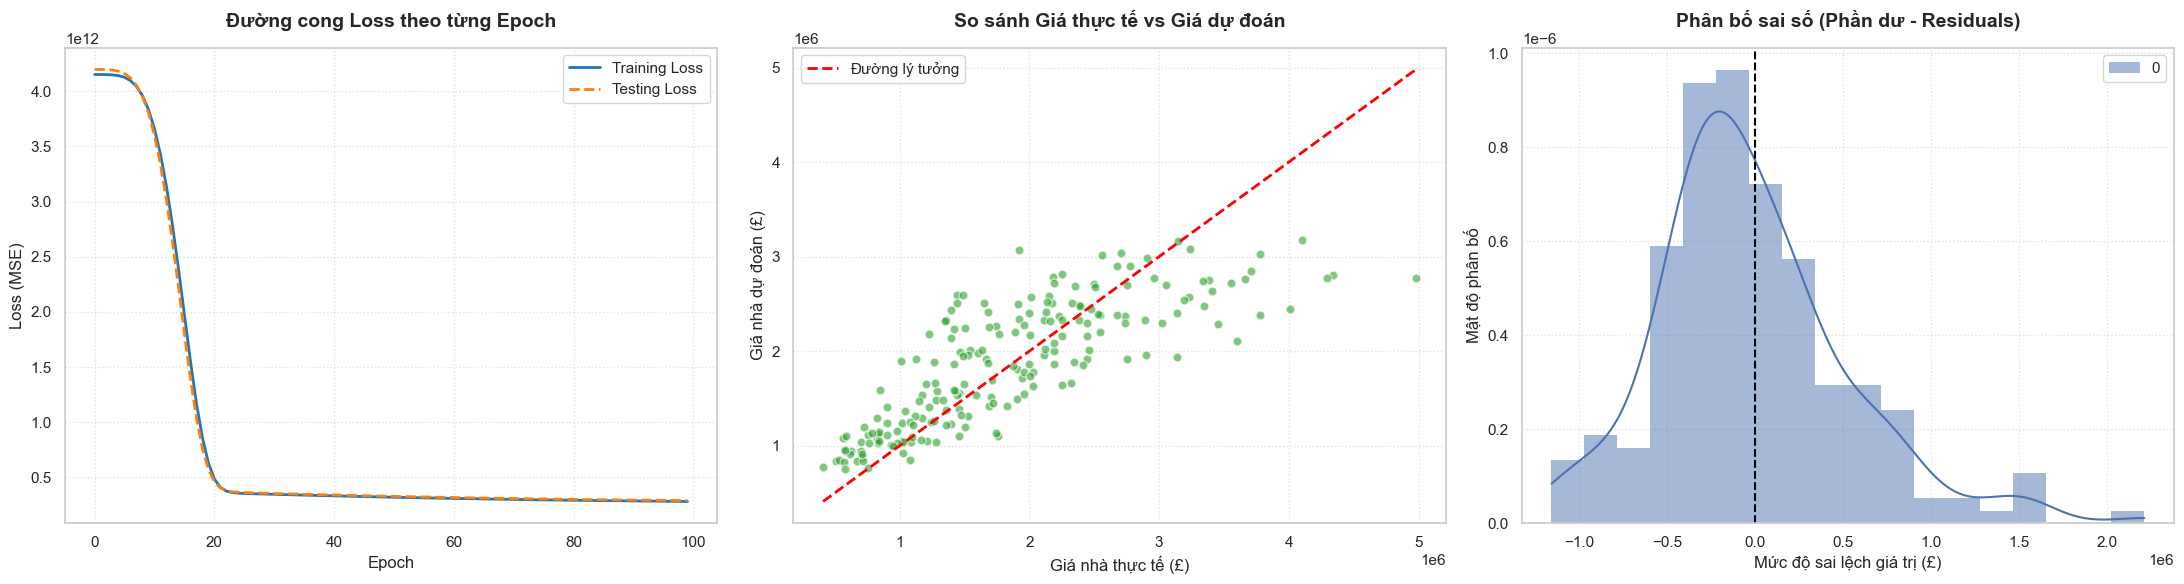

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cấu hình lưới biểu đồ 1 hàng 3 cột để quan sát toàn bộ góc nhìn
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ==========================================
# 1. ĐƯỜNG CONG LOSS (LOSS CURVE)
# ==========================================
axes[0].plot(train_loss_history, label='Training Loss', color='#1f77b4', linewidth=2)
axes[0].plot(test_loss_history, label='Testing Loss', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title('Đường cong Loss theo từng Epoch', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 2. BIỂU ĐỒ DỰ ĐOÁN (ACTUAL VS PREDICTED)
# ==========================================
# Vẽ các điểm dữ liệu thực tế đối chiếu với dự đoán
axes[1].scatter(y_true, y_pred, alpha=0.6, color='#2ca02c', edgecolors='w', s=40)

# Vẽ đường chéo lý tưởng (Perfect Prediction Line)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')

axes[1].set_title('So sánh Giá thực tế vs Giá dự đoán', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Giá nhà thực tế (£)', fontsize=12)
axes[1].set_ylabel('Giá nhà dự đoán (£)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 3. PHÂN BỐ SAI SỐ (RESIDUAL DISTRIBUTION)
# ==========================================
# Sai số (Phần dư) = Giá trị thực tế - Giá trị dự đoán
residuals = y_true - y_pred

sns.histplot(residuals, kde=True, color='#9467bd', ax=axes[2], stat="density", linewidth=0)
# Vẽ đường tham chiếu tại vị trí sai số bằng 0
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1.5)

axes[2].set_title('Phân bố sai số (Phần dư - Residuals)', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Mức độ sai lệch giá trị (£)', fontsize=12)
axes[2].set_ylabel('Mật độ phân bố', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=0.6)

# Tối ưu khoảng cách giữa các biểu đồ và hiển thị
plt.tight_layout()
plt.savefig("model_visualization_results.png", dpi=300)
plt.show()

## 12. Lưu mô hình đã huấn luyện

In [ ]:
import torch
import os

# Tạo thư mục chứa mô hình nếu chưa tồn tại
os.makedirs("saved_models", exist_ok=True)

# ==========================================
# 1. LƯU THAM SỐ MÔ HÌNH (STATE DICT)
# ==========================================
# Cách tối ưu nhất trong PyTorch: Chỉ lưu trọng số (weights) và định thiên (bias)
model_path = "saved_models/house_price_model.pth"
torch.save(model.state_dict(), model_path)

# ==========================================
# 2. LƯU TRẠNG THÁI BỘ TỐI ƯU (TÙY CHỌN)
# ==========================================
# Lưu cấu hình này rất hữu ích nếu bạn muốn huấn luyện tiếp (Resume Training) sau này
optimizer_path = "saved_models/optimizer.pth"
torch.save(optimizer.state_dict(), optimizer_path)

print("=== LƯU MÔ HÌNH HOÀN TẤT ===")
print(f"- Đã lưu trọng số mạng MLP tại : {model_path}")
print(f"- Đã lưu trạng thái Adam tại   : {optimizer_path}")

=== LƯU MÔ HÌNH HOÀN TẤT ===
- Đã lưu trọng số mạng MLP tại : saved_models/house_price_model.pth
- Đã lưu trạng thái Adam tại   : saved_models/optimizer.pth


## 13. Dự đoán dữ liệu mới

In [ ]:
import torch
import pandas as pd
import numpy as np

# ==========================================
# 1. NẠP MÔ HÌNH ĐÃ HUẤN LUYỆN
# ==========================================
loaded_model = HousePriceMLP(input_dim=X.shape[1])
loaded_model.load_state_dict(torch.load("saved_models/house_price_model.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# ==========================================
# 2. KHỞI TẠO TẬP DỮ LIỆU MỚI TỪ USER
# ==========================================
new_houses = pd.DataFrame([
    {
        'Square Meters': 120.5, 'Building Age': 5, 'Floors': 2, 'Balcony': 'Low-level Balcony', 
        'Building Status': 'New', 'Neighborhood': 'Kensington', 'Garden': 'Yes', 'Garage': 'Yes', 
        'Property Type': 'House', 'Heating Type': 'Gas', 'Interior Style': 'Modern', 'View': 'Street', 
        'Materials': 'Brick', 'Bathrooms': 2, 'Bedrooms': 3
    },
    {
        'Square Meters': 65.0, 'Building Age': 45, 'Floors': 1, 'Balcony': 'No Balcony', 
        'Building Status': 'Old', 'Neighborhood': 'Greenwich', 'Garden': 'No', 'Garage': 'No', 
        'Property Type': 'Apartment', 'Heating Type': 'Electric', 'Interior Style': 'Classic', 'View': 'Courtyard', 
        'Materials': 'Concrete', 'Bathrooms': 1, 'Bedrooms': 1
    }
])

# ==========================================
# 3. TIỀN XỬ LÝ VÀ ĐỒNG BỘ CẤU TRÚC ĐẶC TRƯNG
# ==========================================
new_data_processed = pd.DataFrame(columns=X.columns)

new_houses['Balcony'] = new_houses['Balcony'].map(balcony_mapping)
new_houses['Building Status'] = new_houses['Building Status'].map(building_status_mapping)

new_houses['Total_Rooms'] = new_houses['Bedrooms'] + new_houses['Bathrooms']
new_houses['Space_per_Room'] = new_houses['Square Meters'] / new_houses['Total_Rooms']
new_houses['Floors_per_Room_Ratio'] = new_houses['Floors'] / new_houses['Total_Rooms']
new_houses = new_houses.drop(columns=['Bedrooms'])

new_houses_encoded = pd.get_dummies(new_houses, columns=one_hot_cols, dtype=int)

for col in new_data_processed.columns:
    if col in new_houses_encoded.columns:
        new_data_processed[col] = new_houses_encoded[col]
    else:
        new_data_processed[col] = 0

# --- SỬA LỖI TẠI ĐÂY ---
# Chuyển DataFrame sang NumPy Array bằng `.values` trước khi biến đổi để xóa bỏ UserWarning 
# và đảm bảo thứ tự ma trận khớp 100% với lúc fit scaler ban đầu.
new_data_numpy = new_data_processed.values
new_data_scaled = scaler.transform(new_data_numpy)

# ==========================================
# 4. CHUYỂN DỮ LIỆU SANG TENSOR CỦA PYTORCH
# ==========================================
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32).to(device)

# ==========================================
# 5. THỰC HIỆN DỰ ĐOÁN (FORWARD PASS)
# ==========================================
with torch.no_grad():
    raw_predictions = loaded_model(new_data_tensor)
    final_predictions = raw_predictions.cpu().numpy()

# ==========================================
# 6. IN KẾT QUẢ DỰ ĐOÁN MỚI
# ==========================================
print("\n=== KẾT QUẢ DỰ ĐOÁN CẬP NHẬT CHÍNH XÁC ===")
for i, pred_price in enumerate(final_predictions):
    print(f"Nhà mẫu {i+1}: Giá dự đoán dự kiến là: {pred_price[0]:,.2f} £")


=== KẾT QUẢ DỰ ĐOÁN CẬP NHẬT CHÍNH XÁC ===
Nhà mẫu 1: Giá dự đoán dự kiến là: 31,501.59 £
Nhà mẫu 2: Giá dự đoán dự kiến là: 111.40 £
